# Computer Vision Workshop
### From Pixels to Deep Learning — A Hands-On Introduction


---

## Workshop Agenda

| # | Topic | What you'll learn |
|---|-------|--------------------|
| 1 | What is Computer Vision? | Applications & the big picture |
| 2 | Images as Data | Pixels, arrays, channels |
| 3 | Color Spaces | RGB, Grayscale, HSV |
| 4 | Geometric Transformations | Resize, crop, rotate, flip |
| 5 | Image Enhancement | Brightness, contrast, histogram equalization |
| 6 | Noise & Filtering | Adding noise, smoothing/denoising |
| 7 | Morphological Operations | Erosion, dilation, opening, closing |
| 8 | Edge Detection | Sobel, Laplacian, Canny |
| 9 | Feature Detection | Corners (Harris), keypoints (ORB) |
| 10 | Thresholding & Segmentation | Global/Otsu/adaptive thresholding, contours |
| 11 | Deep Learning for CV | CNNs — build & train one on MNIST |
| 12 | Beyond CNNs | GANs, VAEs, Vision Transformers, VLMs (overview) |
| 13 | Wrap-up & Exercises | Recap + challenges to practice |

> Run cells top to bottom. Each section is self-contained but reuses the `astronaut` image loaded in Part 2, so don't skip that cell.


## Setup

Run this once. If a package is missing, uncomment the relevant `pip install` line.


In [1]:
# !pip install opencv-python scikit-image scikit-learn matplotlib numpy tensorflow

import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import data, exposure
from skimage.color import rgb2gray, rgb2hsv

# Reproducibility for any synthetic noise we generate
rng = np.random.default_rng(42)

def show(images, titles, cmap=None, figsize=(14, 4)):
    """Small helper to display a row of images side by side."""
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, im, title in zip(axes, images, titles):
        ax.imshow(im, cmap=cmap)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

print("Setup complete.")


Setup complete.


## Part 1 — What is Computer Vision?

Computer Vision (CV) is the field that teaches machines to **understand and interpret visual information** the way humans do — extracting meaning from images and video rather than just storing pixels.

**Common real-world applications:**
- **Image Classification** — "what is in this image?" (e.g. cat vs dog)
- **Object Detection** — "what objects, and where?" (bounding boxes)
- **Semantic / Instance Segmentation** — pixel-level "what belongs to what"
- **Face Recognition** — identifying / verifying people
- **Optical Character Recognition (OCR)** — reading text in images
- **Medical Imaging** — tumor detection, organ segmentation in X-rays/MRIs
- **Autonomous Vehicles** — lane detection, pedestrian detection
- **Industrial Inspection** — defect detection on assembly lines

A typical **classical CV pipeline** looks like:

`Image Acquisition → Preprocessing → Feature Extraction → Analysis/Modeling → Decision/Output`

Modern **deep learning** pipelines often collapse the middle steps — a CNN learns the features itself instead of us hand-crafting them. We'll build intuition for *both* today: first the classical building blocks (Parts 2–10), then a deep learning model (Part 11).


## Part 2 — Images as Data

To a computer, an image is just a **grid of numbers** (a NumPy array). A color image has 3 values per pixel (Red, Green, Blue); a grayscale image has just 1.

We'll use `astronaut()`, a sample image bundled with `scikit-image` — no download required.


Shape: (512, 512, 3)
Dtype: uint8
Pixel at (0,0): [154 147 151]
Min/Max pixel value: 0 255


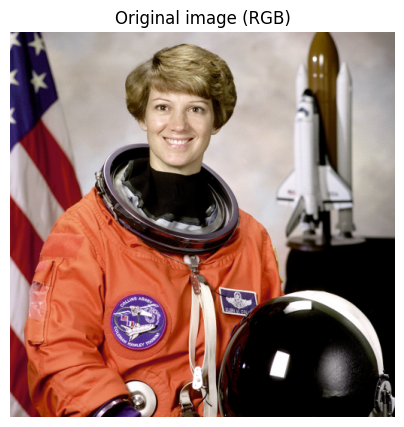

In [2]:
img = data.astronaut()  # built-in sample image, shape (Height, Width, Channels)

print("Shape:", img.shape)       # (512, 512, 3) -> Height x Width x RGB channels
print("Dtype:", img.dtype)       # uint8 -> values 0-255
print("Pixel at (0,0):", img[0, 0])   # [R, G, B] values of the top-left pixel
print("Min/Max pixel value:", img.min(), img.max())

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title("Original image (RGB)")
plt.axis('off')
plt.show()


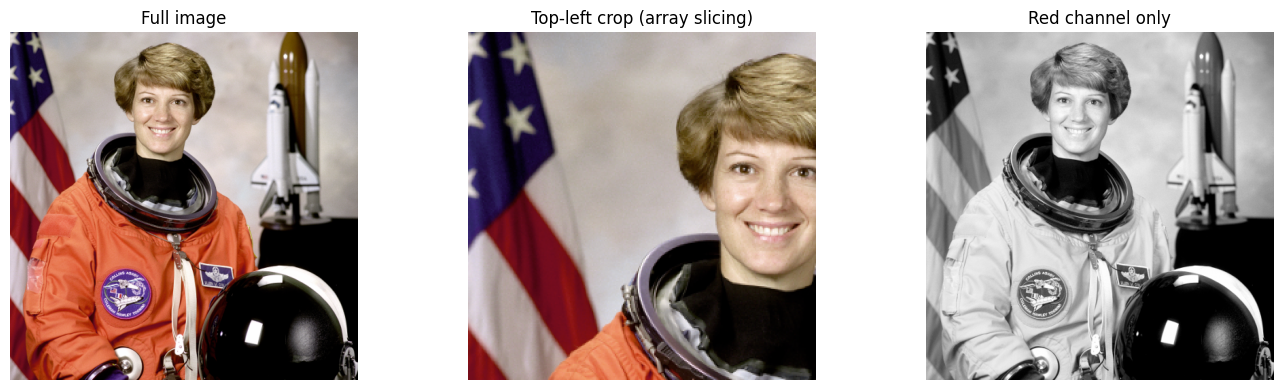

In [3]:
# Slicing an image is just slicing a NumPy array!
top_left_quarter = img[:256, :256]
red_channel_only = img[:, :, 0]

show([img, top_left_quarter, red_channel_only],
     ["Full image", "Top-left crop (array slicing)", "Red channel only"],
     cmap='gray')


## Part 3 — Color Spaces

- **RGB** — how images are usually stored/displayed (Red, Green, Blue).
- **Grayscale** — a single intensity channel; simpler & faster for many classical algorithms.
- **HSV** (Hue, Saturation, Value) — separates *color* from *brightness*, useful for color-based filtering (e.g. "find all red pixels").


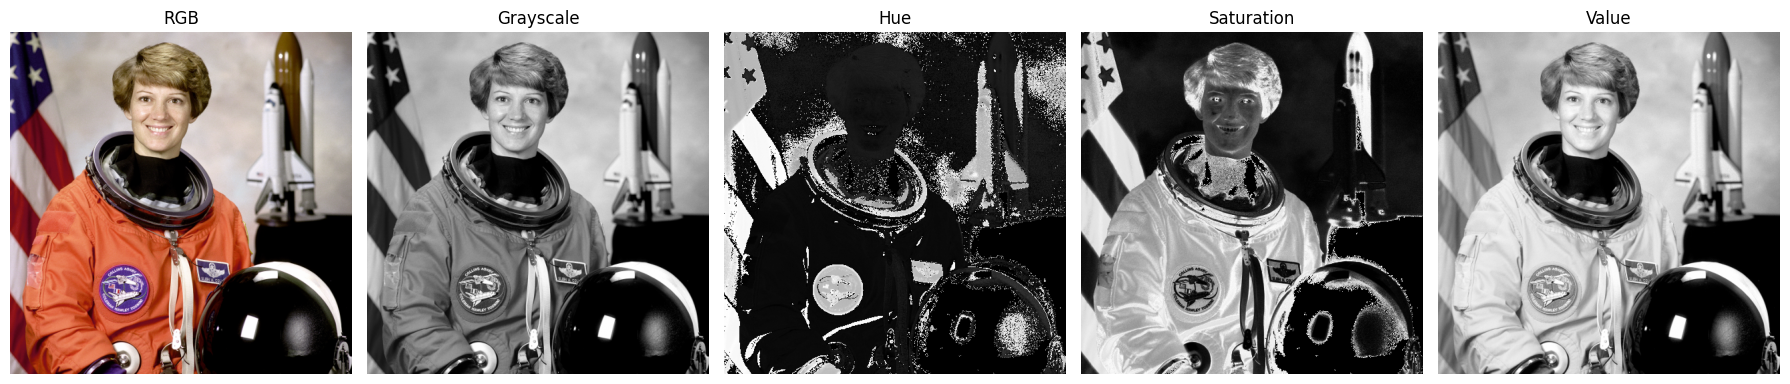

In [4]:
gray = rgb2gray(img)          # values in [0, 1], shape (H, W)
hsv = rgb2hsv(img)             # 3 channels: Hue, Saturation, Value

show([img, gray, hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]],
     ["RGB", "Grayscale", "Hue", "Saturation", "Value"],
     cmap='gray', figsize=(18, 4))


## Part 4 — Geometric Transformations

Basic operations used constantly in CV pipelines for data augmentation and preprocessing: **resize, crop, rotate, flip, translate**. We'll use OpenCV (`cv2`) from here on — it's the most widely used CV library in industry.


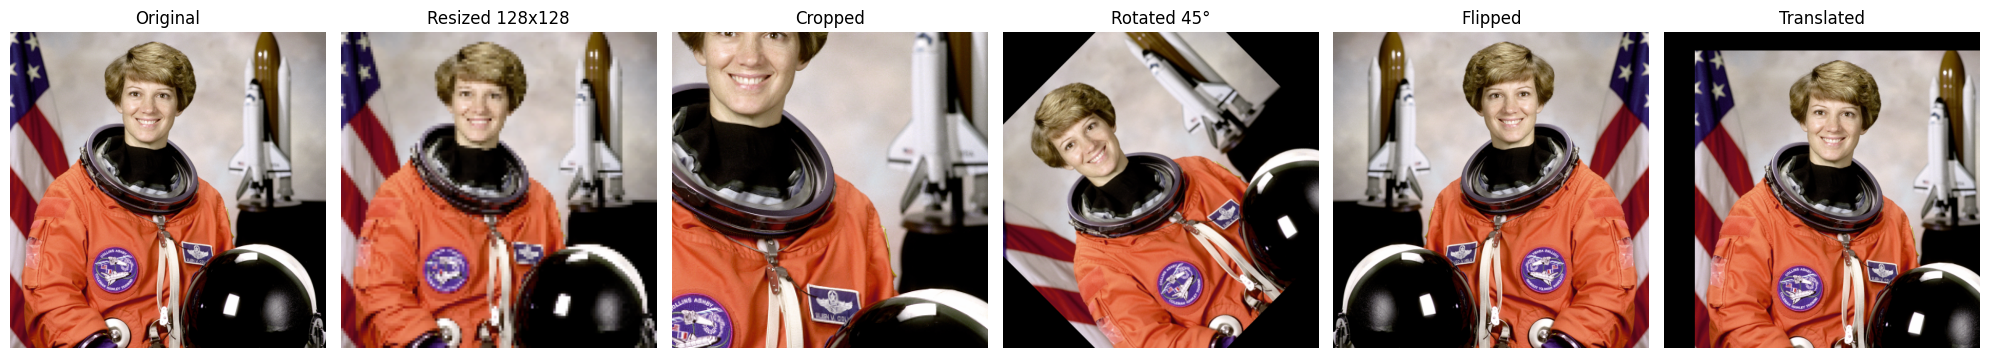

In [5]:
h, w = img.shape[:2]

resized = cv2.resize(img, (128, 128))                       # change dimensions
cropped = img[100:400, 150:450]                             # crop via slicing

M_rotate = cv2.getRotationMatrix2D((w / 2, h / 2), 45, 1.0)  # center, angle, scale
rotated = cv2.warpAffine(img, M_rotate, (w, h))

flipped = cv2.flip(img, 1)                                   # 1 = horizontal flip

M_translate = np.float32([[1, 0, 50], [0, 1, 30]])           # shift 50px right, 30px down
translated = cv2.warpAffine(img, M_translate, (w, h))

show([img, resized, cropped, rotated, flipped, translated],
     ["Original", "Resized 128x128", "Cropped", "Rotated 45°", "Flipped", "Translated"],
     figsize=(20, 4))


## Part 5 — Image Enhancement

Enhancement improves the *visual quality* or *usefulness* of an image without adding new information.

- **Brightness/Contrast adjustment** — simple linear scaling of pixel values: `new = alpha*old + beta`.
- **Histogram Equalization** — redistributes intensity values to spread out the histogram, improving contrast in poorly-lit images.


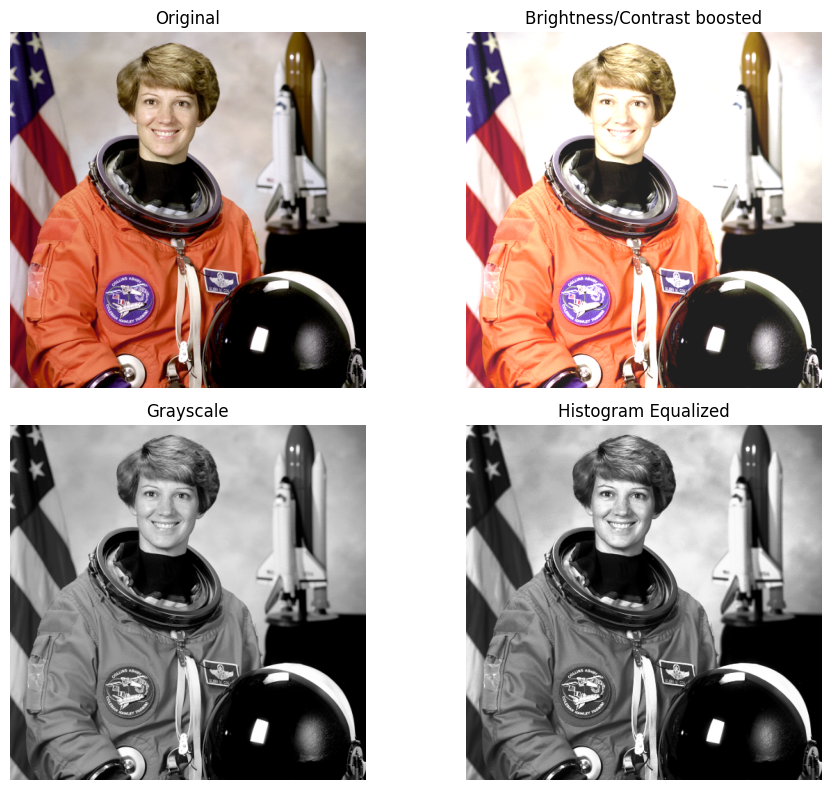

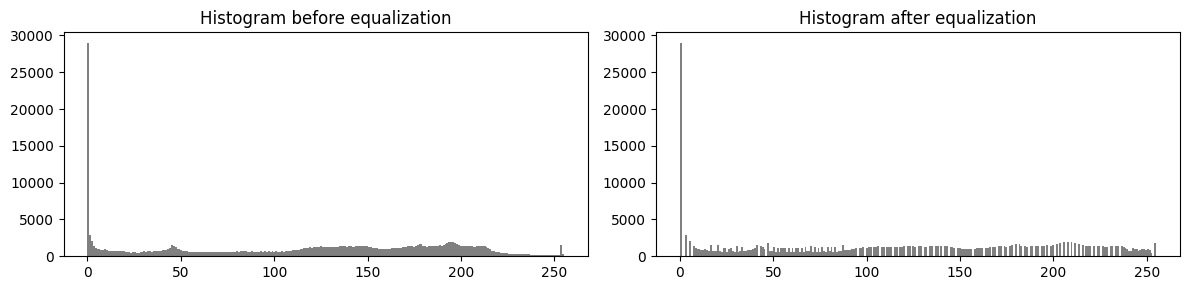

In [6]:
bright_contrast = cv2.convertScaleAbs(img, alpha=1.3, beta=30)  # alpha=contrast, beta=brightness

gray_uint8 = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
equalized = cv2.equalizeHist(gray_uint8)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].imshow(img); axes[0, 0].set_title("Original"); axes[0, 0].axis('off')
axes[0, 1].imshow(bright_contrast); axes[0, 1].set_title("Brightness/Contrast boosted"); axes[0, 1].axis('off')
axes[1, 0].imshow(gray_uint8, cmap='gray'); axes[1, 0].set_title("Grayscale"); axes[1, 0].axis('off')
axes[1, 1].imshow(equalized, cmap='gray'); axes[1, 1].set_title("Histogram Equalized"); axes[1, 1].axis('off')
plt.tight_layout()
plt.show()

# Compare histograms to *see* the effect
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].hist(gray_uint8.ravel(), bins=256, range=(0, 255), color='gray')
axes[0].set_title("Histogram before equalization")
axes[1].hist(equalized.ravel(), bins=256, range=(0, 255), color='gray')
axes[1].set_title("Histogram after equalization")
plt.tight_layout()
plt.show()


## Part 6 — Noise & Filtering (Smoothing/Denoising)

Real-world images are rarely clean. We'll **synthetically add noise** (so we know exactly what we're removing) and then compare filters:

- **Gaussian noise** — random variation following a normal distribution (sensor noise).
- **Salt & pepper noise** — random pixels flipped to pure black/white (transmission errors).
- **Gaussian blur** — smooths using a weighted average, good for Gaussian noise.
- **Median blur** — replaces each pixel with the median of its neighborhood, excellent for salt & pepper noise.
- **Bilateral filter** — smooths while preserving edges.


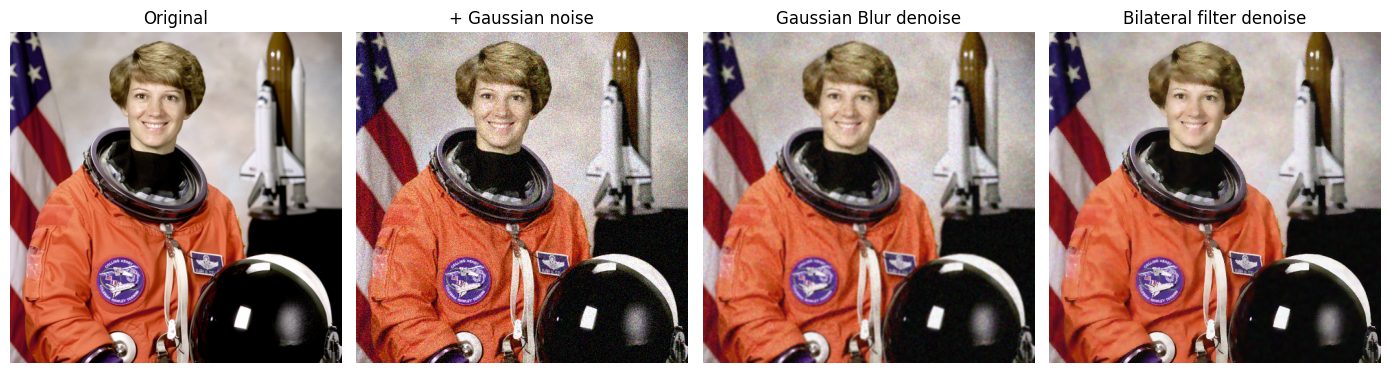

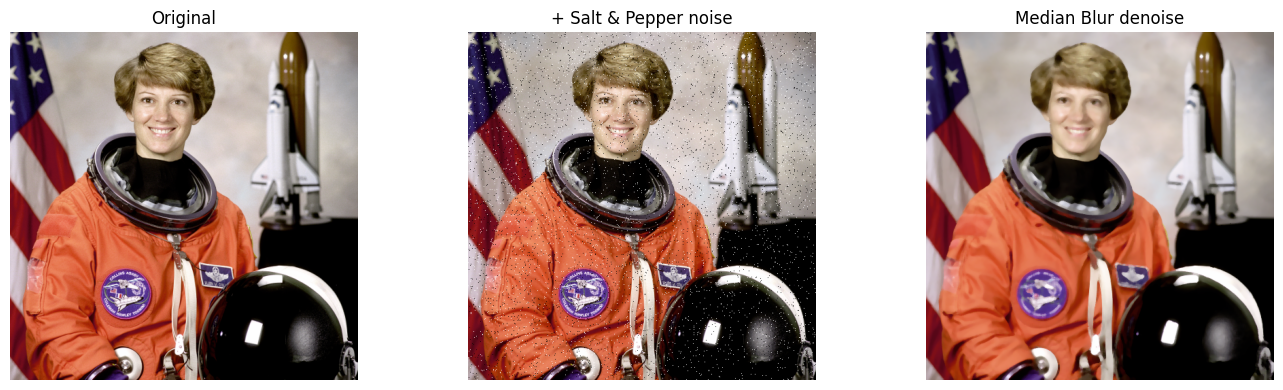

In [7]:
def add_gaussian_noise(image, sigma=25):
    noisy = image.astype(np.float64) + rng.normal(0, sigma, image.shape)
    return np.clip(noisy, 0, 255).astype(np.uint8)

def add_salt_pepper_noise(image, amount=0.02):
    noisy = image.copy()
    mask = rng.random(image.shape[:2])
    noisy[mask < amount / 2] = 0        # pepper
    noisy[mask > 1 - amount / 2] = 255  # salt
    return noisy

gaussian_noisy = add_gaussian_noise(img, sigma=25)
sp_noisy = add_salt_pepper_noise(img, amount=0.03)

gaussian_denoised = cv2.GaussianBlur(gaussian_noisy, (5, 5), 0)
median_denoised = cv2.medianBlur(sp_noisy, 5)
bilateral_denoised = cv2.bilateralFilter(gaussian_noisy, 9, 75, 75)

show([img, gaussian_noisy, gaussian_denoised, bilateral_denoised],
     ["Original", "+ Gaussian noise", "Gaussian Blur denoise", "Bilateral filter denoise"])

show([img, sp_noisy, median_denoised],
     ["Original", "+ Salt & Pepper noise", "Median Blur denoise"])


## Part 7 — Morphological Operations

These operate on **binary (black & white) images** and are the classic tool for cleaning up shapes, e.g. after thresholding a document scan or a segmentation mask.

- **Erosion** — shrinks white regions (removes small white noise specks).
- **Dilation** — grows white regions (fills small black holes).
- **Opening** = Erosion → Dilation (removes small noise, keeps shape size).
- **Closing** = Dilation → Erosion (fills small holes, keeps shape size).

We'll build our own **synthetic binary image** (a rectangle + a circle) and sprinkle noise on it so the effect of each operation is crystal clear.


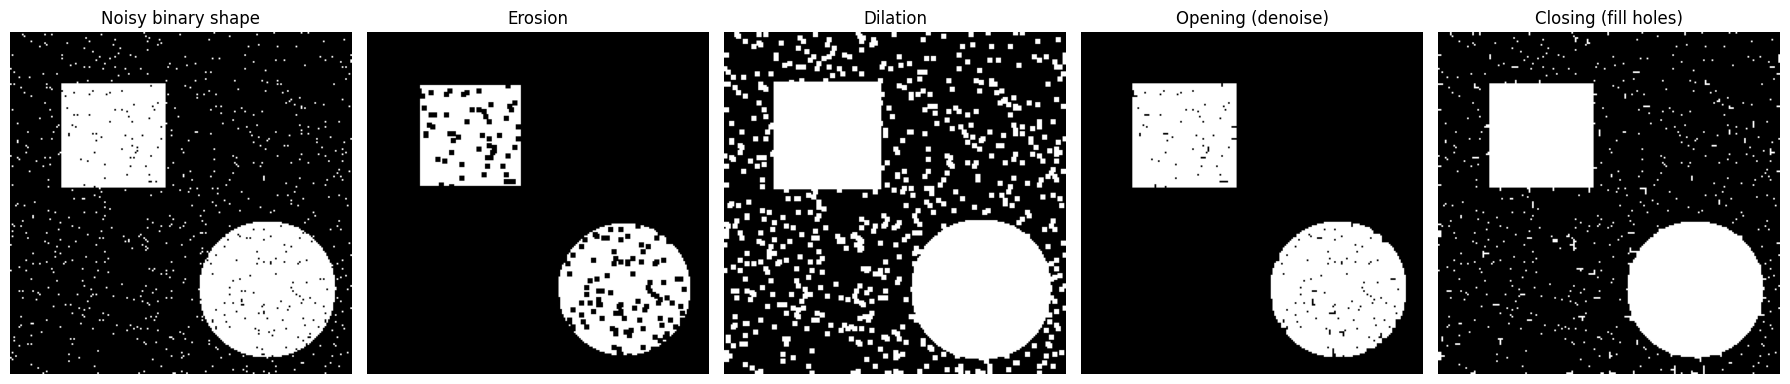

In [8]:
canvas = np.zeros((200, 200), dtype=np.uint8)
cv2.rectangle(canvas, (30, 30), (90, 90), 255, -1)
cv2.circle(canvas, (150, 150), 40, 255, -1)

# Sprinkle random noise (flip ~2% of pixels)
noise_mask = rng.random(canvas.shape) < 0.02
canvas_noisy = canvas.copy()
canvas_noisy[noise_mask] = 255 - canvas_noisy[noise_mask]

kernel = np.ones((3, 3), np.uint8)
erosion = cv2.erode(canvas_noisy, kernel, iterations=1)
dilation = cv2.dilate(canvas_noisy, kernel, iterations=1)
opening = cv2.morphologyEx(canvas_noisy, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(canvas_noisy, cv2.MORPH_CLOSE, kernel)

show([canvas_noisy, erosion, dilation, opening, closing],
     ["Noisy binary shape", "Erosion", "Dilation", "Opening (denoise)", "Closing (fill holes)"],
     cmap='gray', figsize=(18, 4))


## Part 8 — Edge Detection

Edges are where pixel intensity changes sharply — usually object boundaries. Detecting them is a key preprocessing step for shape analysis and was, historically, one of the first "features" used in CV.

- **Sobel** — approximates the image gradient in x and y directions.
- **Laplacian** — second-derivative based, highlights regions of rapid intensity change.
- **Canny** — a multi-stage, well-tuned edge detector (the most commonly used one in practice).


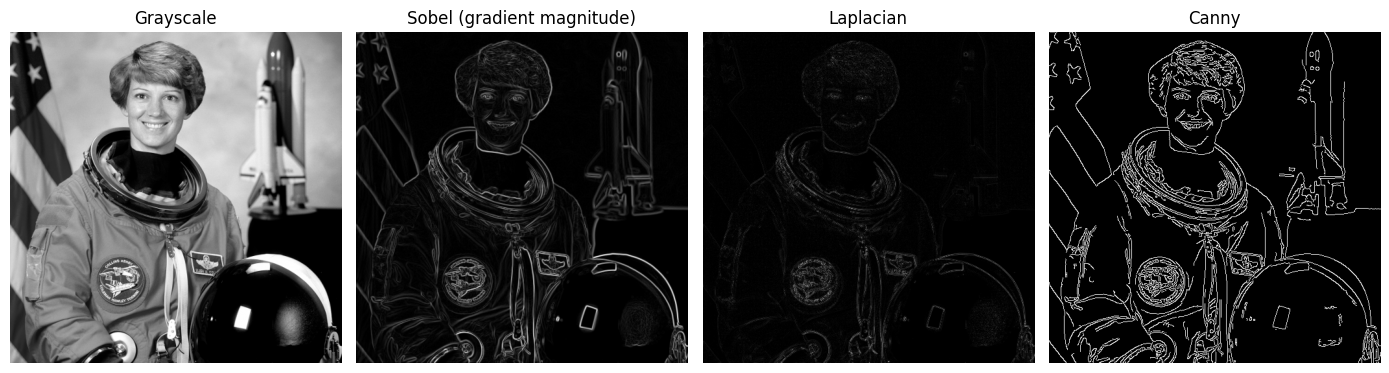

In [9]:
sobel_x = cv2.Sobel(gray_uint8, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray_uint8, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = cv2.magnitude(sobel_x, sobel_y)

laplacian = cv2.Laplacian(gray_uint8, cv2.CV_64F)
canny_edges = cv2.Canny(gray_uint8, 100, 200)  # (image, lower_threshold, upper_threshold)

show([gray_uint8, np.abs(sobel_combined), np.abs(laplacian), canny_edges],
     ["Grayscale", "Sobel (gradient magnitude)", "Laplacian", "Canny"],
     cmap='gray')


## Part 9 — Feature Detection & Description

Beyond edges, we often want distinctive **keypoints** that can be matched across images (used in panorama stitching, object tracking, image retrieval, 3D reconstruction).

- **Harris Corner Detector** — finds points where intensity changes sharply in *all* directions (corners).
- **ORB** (Oriented FAST and Rotated BRIEF) — a fast, free alternative to patented SIFT/SURF; gives both keypoint locations *and* a descriptor vector for matching.


ORB found 300 keypoints. Descriptor vector shape per keypoint: 32


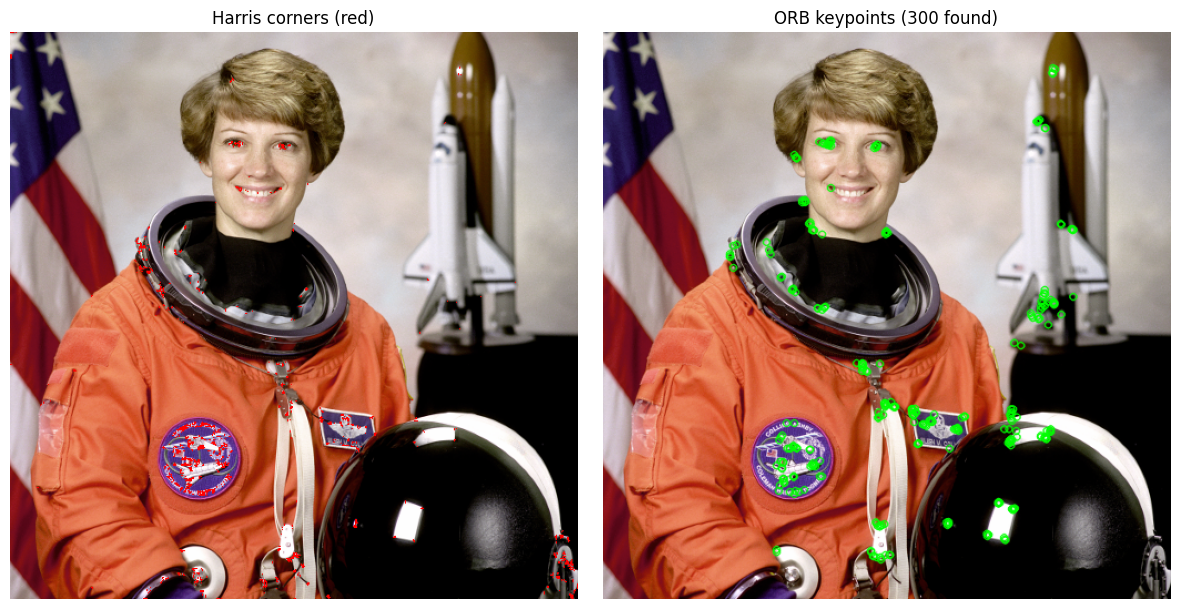

In [10]:
# Harris corners
gray_f32 = np.float32(gray_uint8)
harris_response = cv2.cornerHarris(gray_f32, blockSize=2, ksize=3, k=0.04)
img_harris = img.copy()
img_harris[harris_response > 0.01 * harris_response.max()] = [255, 0, 0]  # mark corners red

# ORB keypoints + descriptors
orb = cv2.ORB_create(nfeatures=300)
keypoints, descriptors = orb.detectAndCompute(img, None)
img_orb = cv2.drawKeypoints(img, keypoints, None, color=(0, 255, 0), flags=0)

print(f"ORB found {len(keypoints)} keypoints. Descriptor vector shape per keypoint: {descriptors.shape[1]}")

show([img_harris, img_orb], ["Harris corners (red)", f"ORB keypoints ({len(keypoints)} found)"], figsize=(12, 6))


## Part 10 — Thresholding & Segmentation

Segmentation splits an image into meaningful regions. The simplest approach is **thresholding**: turn pixels into black/white based on intensity.

We'll use `coins()`, another `scikit-image` built-in sample (grayscale image of coins on a background) — great for demonstrating thresholding and contour detection.


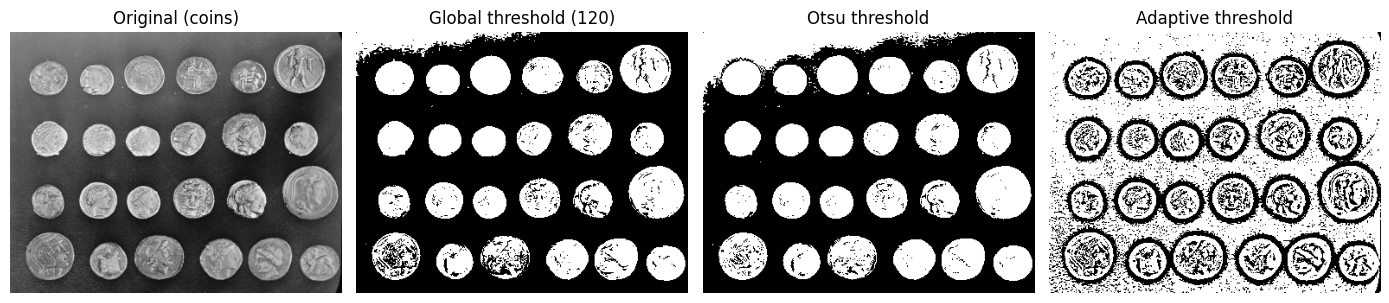

In [11]:
coins = data.coins()

# Global fixed threshold
_, thresh_global = cv2.threshold(coins, 120, 255, cv2.THRESH_BINARY)

# Otsu's method automatically picks the optimal global threshold
_, thresh_otsu = cv2.threshold(coins, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Adaptive threshold: different threshold per local region -> robust to uneven lighting
thresh_adaptive = cv2.adaptiveThreshold(coins, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                        cv2.THRESH_BINARY, 21, 5)

show([coins, thresh_global, thresh_otsu, thresh_adaptive],
     ["Original (coins)", "Global threshold (120)", "Otsu threshold", "Adaptive threshold"],
     cmap='gray')


Detected 96 objects (coins + background artifacts)


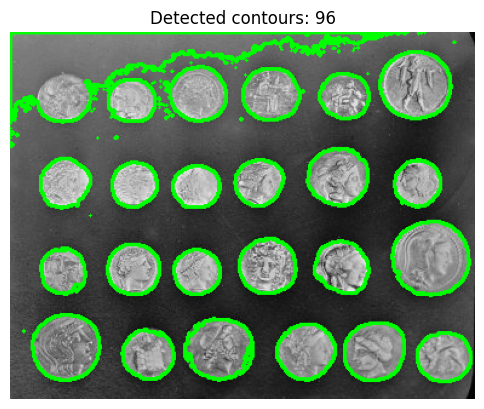

In [12]:
# Find & draw contours (connected regions) on the Otsu-thresholded image
contours, _ = cv2.findContours(thresh_otsu, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

coins_bgr = cv2.cvtColor(coins, cv2.COLOR_GRAY2BGR)
cv2.drawContours(coins_bgr, contours, -1, (0, 255, 0), 2)

print(f"Detected {len(contours)} objects (coins + background artifacts)")

plt.figure(figsize=(6, 5))
plt.imshow(coins_bgr)
plt.title(f"Detected contours: {len(contours)}")
plt.axis('off')
plt.show()


## Part 11 — Deep Learning for Computer Vision: CNNs

Everything so far used **hand-crafted rules** (we told the computer exactly how to find edges, corners, etc). **Convolutional Neural Networks (CNNs)** flip this around: the network *learns* the best filters/features directly from data.

**Core CNN building blocks:**
- **Convolution layer** — slides small learnable filters over the image (just like our Sobel kernel earlier, but the numbers in the filter are *learned*, not hand-picked).
- **Activation (ReLU)** — adds non-linearity.
- **Pooling layer** — downsamples, keeping the strongest signals (e.g. Max Pooling).
- **Fully connected (Dense) layer** — combines features for final classification.

We'll train a small CNN on **MNIST** (handwritten digits 0–9) — the classic "hello world" dataset for image classification. It downloads automatically via Keras (~11MB, needs internet the first run).

> No internet at the workshop venue? Swap in `sklearn.datasets.load_digits()` (8x8 digit images, bundled with scikit-learn, no internet needed) — a commented-out fallback is included below.


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train images: (60000, 28, 28) Test images: (10000, 28, 28)


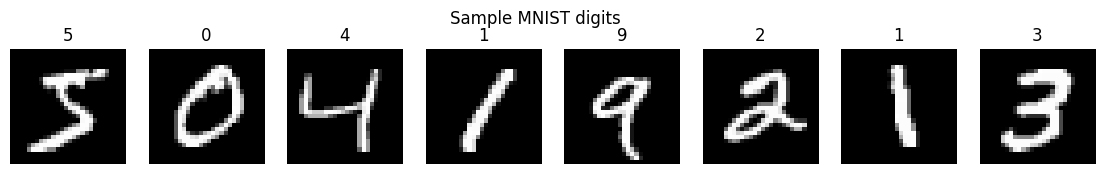

In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ---- Load data ----
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# ---- OFFLINE FALLBACK (uncomment if you have no internet access) ----
# from sklearn.datasets import load_digits
# from sklearn.model_selection import train_test_split
# digits = load_digits()
# X, y = digits.images, digits.target
# x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train images:", x_train.shape, "Test images:", x_test.shape)

# Normalize pixel values to [0, 1] and add a channel dimension (H, W, 1)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow(x_train[i, :, :, 0], cmap='gray')
    ax.set_title(str(y_train[i]))
    ax.axis('off')
plt.suptitle("Sample MNIST digits")
plt.show()


In [14]:
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(64, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(pool_size=2),
    layers.Flatten(),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax"),  # 10 classes: digits 0-9
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 91ms/step - accuracy: 0.9032 - loss: 0.3284 - val_accuracy: 0.9772 - val_loss: 0.0813
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 37s 87ms/step - accuracy: 0.9709 - loss: 0.0947 - val_accuracy: 0.9832 - val_loss: 0.0556
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 37s 87ms/step - accuracy: 0.9785 - loss: 0.0685 - val_accuracy: 0.9865 - val_loss: 0.0474
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 36s 84ms/step - accuracy: 0.9820 - loss: 0.0575 - val_accuracy: 0.9890 - val_loss: 0.0403
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 86ms/step - accuracy: 0.9839 - loss: 0.0513 - val_accuracy: 0.9873 - val_loss: 0.0413
Test accuracy: 0.9859


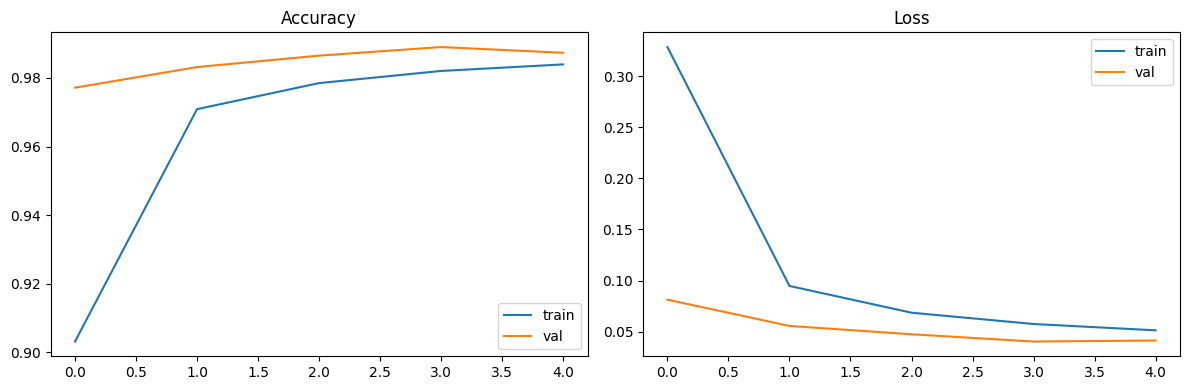

In [15]:
history = model.fit(x_train, y_train, batch_size=128, epochs=5, validation_split=0.1)

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy'); axes[0].legend()
axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss'); axes[1].legend()
plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


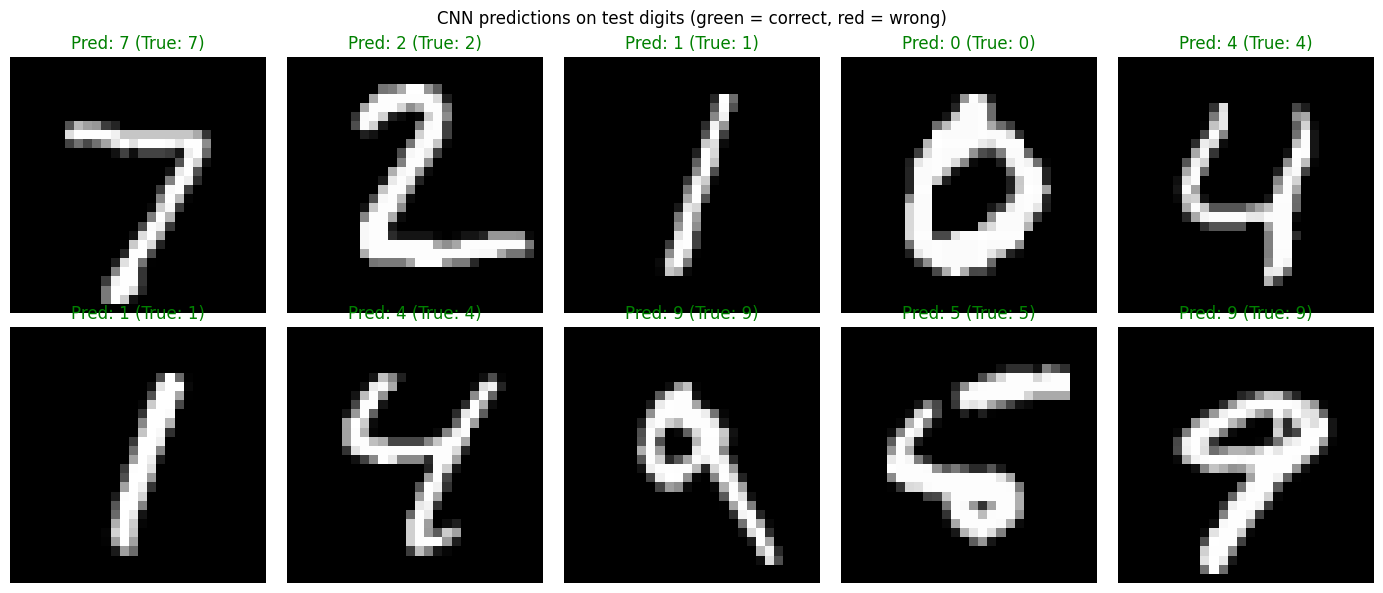

In [16]:
# Visualize predictions on a few test images
preds = model.predict(x_test[:10])
pred_labels = np.argmax(preds, axis=1)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(x_test[i, :, :, 0], cmap='gray')
    correct = pred_labels[i] == y_test[i]
    color = 'green' if correct else 'red'
    ax.set_title(f"Pred: {pred_labels[i]} (True: {y_test[i]})", color=color)
    ax.axis('off')s
plt.suptitle("CNN predictions on test digits (green = correct, red = wrong)")
plt.tight_layout()
plt.show()


## Part 12 — Beyond CNNs (Overview)

CNNs are the workhorse of modern CV, but the field has moved fast. Good to know for context, even without diving into code today:

- **GANs (Generative Adversarial Networks)** — two networks (a Generator and a Discriminator) compete; the Generator learns to create realistic images (e.g. face generation, image-to-image translation).
- **VAEs (Variational Autoencoders)** — learn a compressed latent representation of images and can generate new samples from it; more stable to train than GANs, commonly used for representation learning.
- **Vision Transformers (ViT)** — apply the Transformer architecture (originally from NLP) to images by splitting them into patches; now rival/exceed CNNs on many benchmarks, especially with large datasets.
- **Vision-Language Models (VLMs)** — models like CLIP that jointly understand images *and* text, enabling zero-shot classification, image search by text description, and captioning.
- **Transfer Learning** — instead of training from scratch, start from a model pretrained on a huge dataset (e.g. ImageNet) and fine-tune on your smaller dataset — the standard practice in real-world projects.

This is a good "map" to have — if your project needs generation, look at GANs/VAEs; if it needs large-scale accuracy, consider ViT; if it needs to reason about images *and* text together, look at VLMs.
